# MPSlib: Estimation

Johansson and Hansen (2021) demonstrate how to perform MPS estimation to directly obtain
conditional statistics without the need for simulation.

    O.par['do_estimation']  # [0]: simulation, [1]: estimation

See details about MPS estimation in:
[Jóhannsson, Óli D., and Thomas Mejer Hansen. "Estimation using multiple-point statistics." Computers & Geosciences 156 (2021)](https://doi.org/10.1016/j.cageo.2021.104894).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mpslib as mps

## Setup

In [2]:
O = mps.mpslib(method='mps_genesim', n_max_cpdf_count=100, simulation_grid_size=np.array([28, 43, 1]))
#O = mps.mpslib(method='mps_snesim_tree', n_multiple_grids=1, simulation_grid_size=np.array([28, 43, 1]))
O.par['verbose_level'] = 0

# Set hard data
d_hard = np.array([[ 3,  3, 0, 1],
                   [ 8,  8, 0, 0],
                   [12,  3, 0, 1]])

# Set soft data
d_soft = np.array([[ 20, 20, 0, 0.001, 0.999]])

O.d_hard = d_hard
O.d_soft = d_soft

# Only co-located soft data
O.par['n_cond_soft'] = len(O.d_soft)
O.par['n_cond'] = len(O.d_hard)

# Set training image
O.ti = mps.trainingimages.strebelle(di=3, coarse3d=1)[0]

Using mps_genesim installed in /mnt/d/PROGRAMMING/mpslib (scikit-mps in /mnt/d/PROGRAMMING/mpslib/scikit-mps/mpslib/mpslib.py)


## Estimation

Run MPS estimation to obtain conditional probability maps and conditional entropy.

loading entropy from ti.dat_ent_0.gslib
loading estimation from ti.dat_cg_0.gslib
loading estimation from ti.dat_cg_1.gslib
Time used to perform MPS estimation: 37.2s


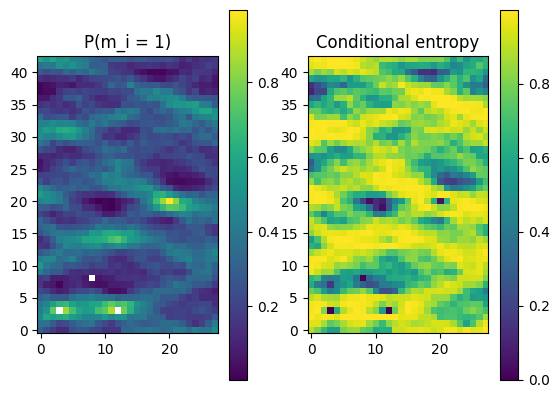

In [3]:
O.par['n_cond'] = len(O.d_hard) # For estimation, n_cond never needs to exceed the number of actual conditional data points
O.par['n_real'] = 1
O.par['do_estimation'] = 1
O.par['do_entropy'] = 1
O.par['n_max_cpdf_count'] = 100000000  # Needs to be large to compute the full conditional distribution
O.par['n_max_ite'] = 50000 # the higher the better, but estimation is typically fast so this is not a problem
O.delete_local_files()
O.remove_gslib_after_simulation = 1

O.run()
print('Time used to perform MPS estimation: %4.1fs' % (O.time))

# Get P(m_i == 1)
P1 = O.est[1][:, :, 0].T
# Get H(m_i) - conditional entropy
H = O.Hcond[:, :, 0].T

plt.figure()
plt.subplot(121)
plt.imshow(P1)
plt.colorbar()
plt.title('P(m_i = 1)')
plt.gca().invert_yaxis()
plt.subplot(122)
plt.imshow(H)
plt.colorbar()
plt.title('Conditional entropy')
plt.gca().invert_yaxis()
plt.show()

## Simulation

Run MPS simulation for comparison with the estimation result.

parallel: Using 64 of max 64 threads (128 logical processors)
Time used to perform MPS simulation: 51.7s


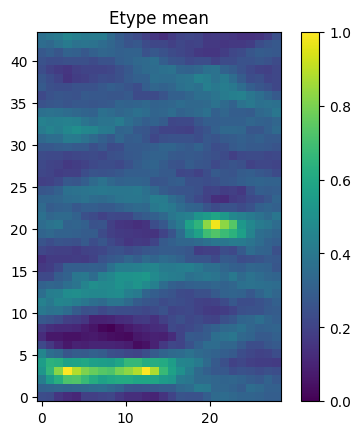

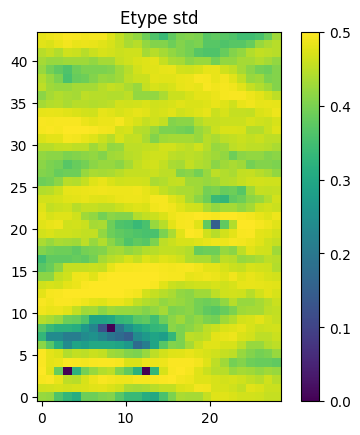

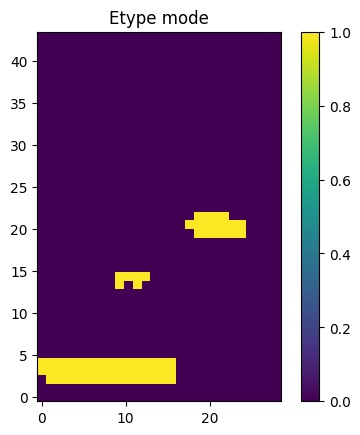

In [4]:
O.par['n_real'] = 2*64
O.par['n_cond'] = 25  # For simulation, n_cond typically needs to be higher to obtain reasonable pattern reproduction

O.par['do_estimation'] = 0
O.par['n_max_cpdf_count'] = 1   # Direct sampling mode
O.par['n_max_ite'] = 10000    # Must be large enough for each thread to find a match
O.par['n_threads'] = -1
O.delete_local_files()
O.remove_gslib_after_simulation = 1

O.run_parallel()
print('Time used to perform MPS simulation: %4.1fs' % (O.time))
O.plot_etype()

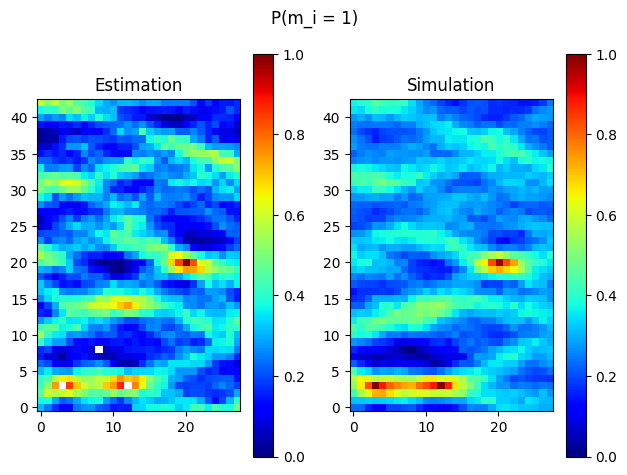

In [5]:
plt.figure()
plt.subplot(121)
plt.imshow(P1, vmin=0, vmax=1, cmap='jet' )
plt.colorbar()
plt.title('Estimation')
plt.gca().invert_yaxis()
plt.subplot(122)
plt.imshow(O.etype()[0].T, vmin=0, vmax=1, cmap='jet')
plt.colorbar()
plt.title('Simulation')
plt.gca().invert_yaxis()
plt.suptitle('P(m_i = 1)')
plt.tight_layout()
plt.show()